In [38]:
import pandas as pd
import numpy as nu
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
import tensorflow as tf

In [40]:
data=tf.keras.preprocessing.image_dataset_from_directory("Oxford 17 Flowers")

Found 1360 files belonging to 16 classes.


(32, 256, 256, 3)


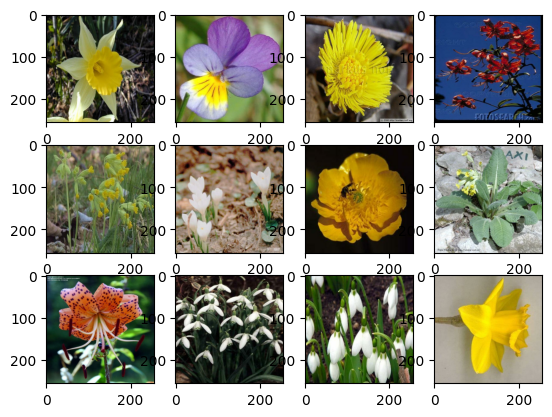

In [41]:
for i,j in data.take(1):
    print(i.shape)
    for k in range(0,12):
        plt.subplot(3,4,k+1)
        plt.imshow(i[k].numpy().astype('uint8'))
    

In [42]:
train_ds_size=len(data)*0.8
train_ds_size

34.4

In [43]:
train_ds=data.take(34)

In [44]:
test_ds=data.skip(34)

In [45]:
c=data.class_names

In [46]:
c

['Bluebell',
 'Buttercup',
 'Coltsfoot',
 'Cowslip',
 'Crocus',
 'Daffodil',
 'Daisy',
 'Dandelion',
 'Fritillary',
 'Iris',
 'Lilyvalley',
 'Pansy',
 'Snowdrop',
 'Tigerlily',
 'Tulip',
 'Windflower']

In [47]:
len(data)

43

In [52]:
p={}
for i in range(43):
    for j,k in data.take(i):
        for m in range(32):
            p[c[k[m]]]=0
            

In [53]:
p

{'Tigerlily': 0,
 'Buttercup': 0,
 'Coltsfoot': 0,
 'Lilyvalley': 0,
 'Snowdrop': 0,
 'Pansy': 0,
 'Tulip': 0,
 'Daffodil': 0,
 'Dandelion': 0,
 'Crocus': 0,
 'Daisy': 0,
 'Windflower': 0,
 'Fritillary': 0,
 'Cowslip': 0,
 'Bluebell': 0,
 'Iris': 0}

In [55]:

for i in range(43):
    for j,k in data.take(i):
        for m in range(32):
            p[c[k[m]]]=p[c[k[m]]]+1

In [56]:
p

{'Tigerlily': 2923,
 'Buttercup': 2963,
 'Coltsfoot': 5821,
 'Lilyvalley': 2978,
 'Snowdrop': 2429,
 'Pansy': 3155,
 'Tulip': 3093,
 'Daffodil': 2593,
 'Dandelion': 3094,
 'Crocus': 2785,
 'Daisy': 2903,
 'Windflower': 3185,
 'Fritillary': 2834,
 'Cowslip': 3288,
 'Bluebell': 2583,
 'Iris': 2825}

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'Tigerlily'),
  Text(1, 0, 'Buttercup'),
  Text(2, 0, 'Coltsfoot'),
  Text(3, 0, 'Lilyvalley'),
  Text(4, 0, 'Snowdrop'),
  Text(5, 0, 'Pansy'),
  Text(6, 0, 'Tulip'),
  Text(7, 0, 'Daffodil'),
  Text(8, 0, 'Dandelion'),
  Text(9, 0, 'Crocus'),
  Text(10, 0, 'Daisy'),
  Text(11, 0, 'Windflower'),
  Text(12, 0, 'Fritillary'),
  Text(13, 0, 'Cowslip'),
  Text(14, 0, 'Bluebell'),
  Text(15, 0, 'Iris')])

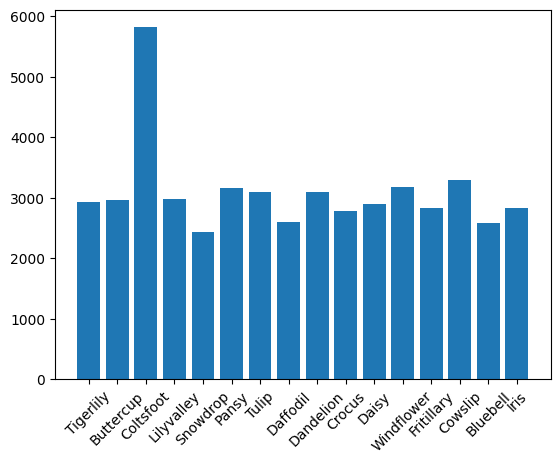

In [60]:
plt.bar(p.keys(),p.values())
plt.xticks(rotation=45)

In [69]:
#height and width of images
h=[]
w=[]
for i in range(43):
    for j,k in data.take(i):
        h.append(j.shape[0])
        w.append(j.shape[1])
        
       
            

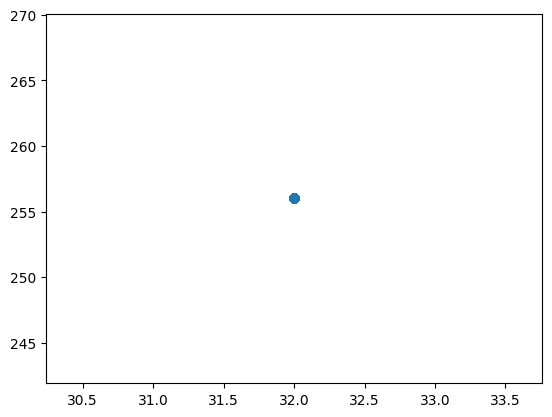

In [70]:
plt.scatter(h,w)

In [72]:
#most common aspect ratio
a=[]
for i in range(len(w)):
    a.append(round(w[i]/h[i],2))

In [73]:
from collections import Counter
count=Counter(a).most_common(5)


In [74]:
count

[(8.0, 903)]

In [75]:
import tensorflow as tf

total_bytes = 0
num_images = 0

for img, _ in data.take(43):
    total_bytes += tf.size(img).numpy() * img.dtype.size
    num_images += 1

avg_bytes = total_bytes / num_images
avg_kb = avg_bytes / 1024
avg_mb = avg_kb / 1024

print(f"Average in-memory image size: {avg_kb:.2f} KB ({avg_mb:.4f} MB)")

Average in-memory image size: 24290.23 KB (23.7209 MB)


In [80]:
def calculate_brightness(image_tensor):
    return tf.reduce_mean(image_tensor)

def calculate_contrast(image_tensor):
    return tf.math.reduce_std(image_tensor)

def calculate_sharpness(image_tensor):
    edges = tf.image.sobel_edges(image_tensor)
    sharpness = tf.reduce_mean(tf.abs(edges))
    return sharpness
b=[]
c=[]
s=[]
for img, _ in data:
    
    
    brightness = calculate_brightness(img)
    contrast = calculate_contrast(img)
    sharpness=calculate_sharpness(img)
    b.append(brightness)
    c.append(contrast)
    s.append(sharpness)
    
    
       


In [87]:
nu.array(b).mean()

np.float32(94.37859)

In [88]:
nu.array(c).mean()

np.float32(69.105774)

In [89]:
nu.array(s).mean()

np.float32(49.53039)

In [90]:
def downsample_image(image_tensor, size=(32, 32)):
    image = tf.image.resize(image_tensor, size)  # Resize to 32x32 pixels
    return image

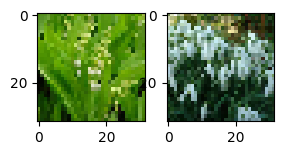

In [99]:
for img, _ in data.take(3):
    for i in range(2):
        plt.subplot(3,4,i+1)
        downsample_imag=downsample_image(img[i])
        plt.imshow(downsample_imag.numpy().astype('uint8'))

In [101]:
def plot_rgb_histogram(image_tensor, bins=256):
    # Separate RGB channels
    r, g, b = tf.split(image_tensor, num_or_size_splits=3, axis=-1)
    
    # Convert tensors to numpy arrays
    r = r.numpy().flatten().astype("uint8")
    g = g.numpy().flatten().astype("uint8")
    b = b.numpy().flatten().astype("uint8")
    
    # Plot histograms for each channel (Red, Green, Blue)
    plt.figure(figsize=(10, 6))
    plt.subplot(131)
    plt.hist(r, bins=bins, range=(0, 255), color='red', alpha=0.7)
    plt.title("Red Channel")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    
    plt.subplot(132)
    plt.hist(g, bins=bins, range=(0, 255), color='green', alpha=0.7)
    plt.title("Green Channel")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    
    plt.subplot(133)
    plt.hist(b, bins=bins, range=(0, 255), color='blue', alpha=0.7)
    plt.title("Blue Channel")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()


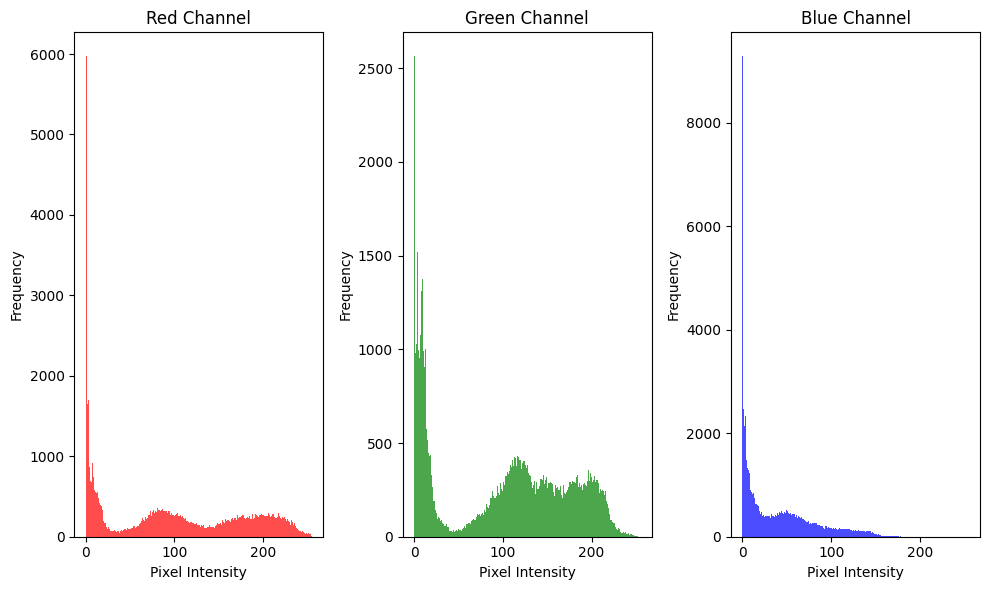

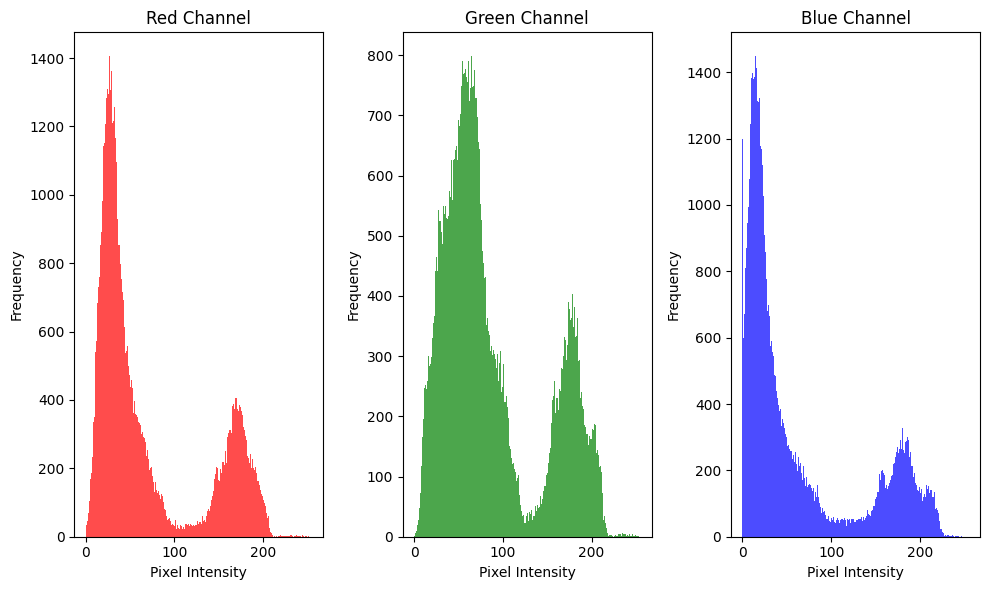

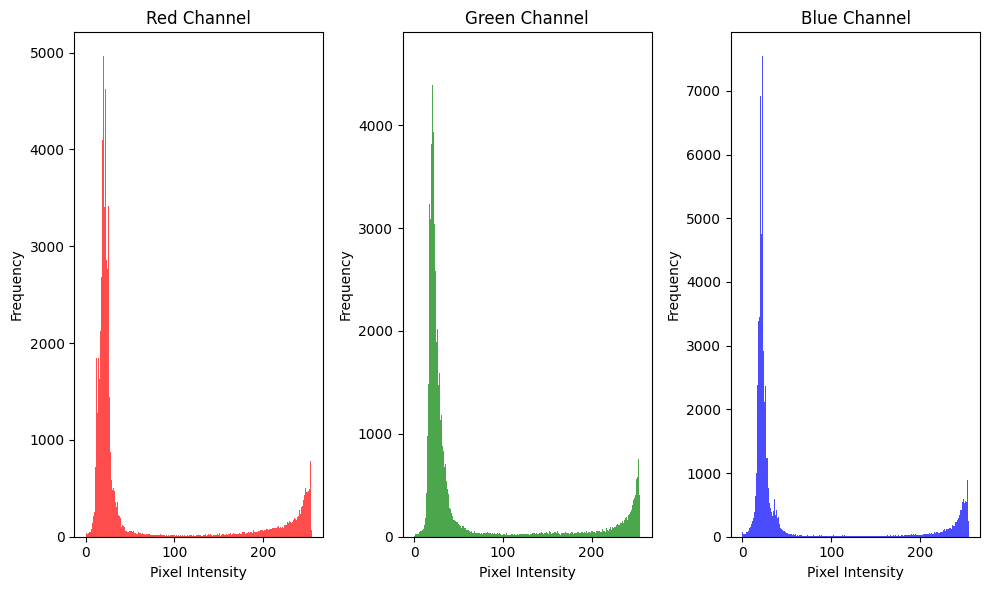

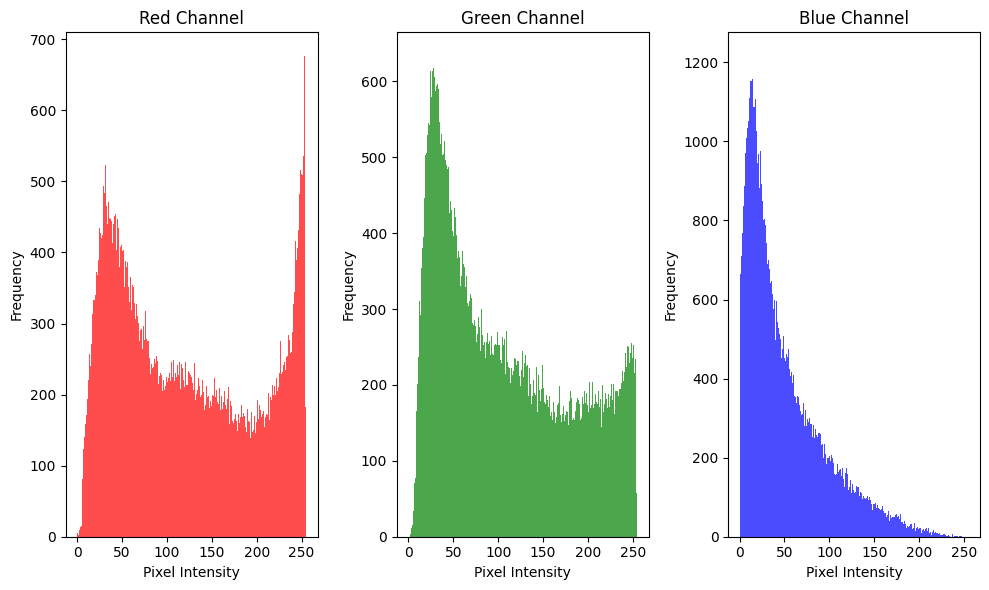

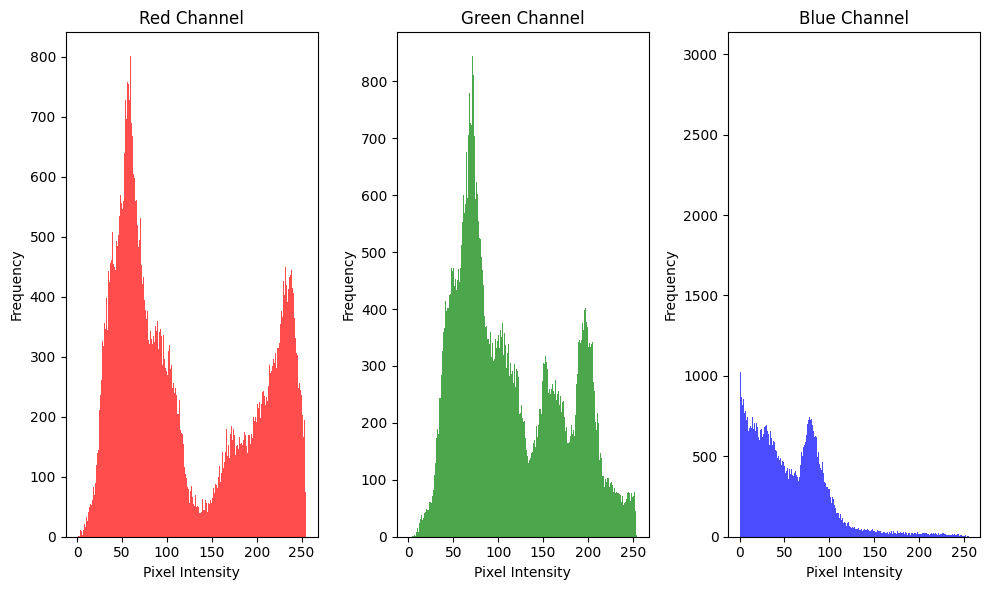

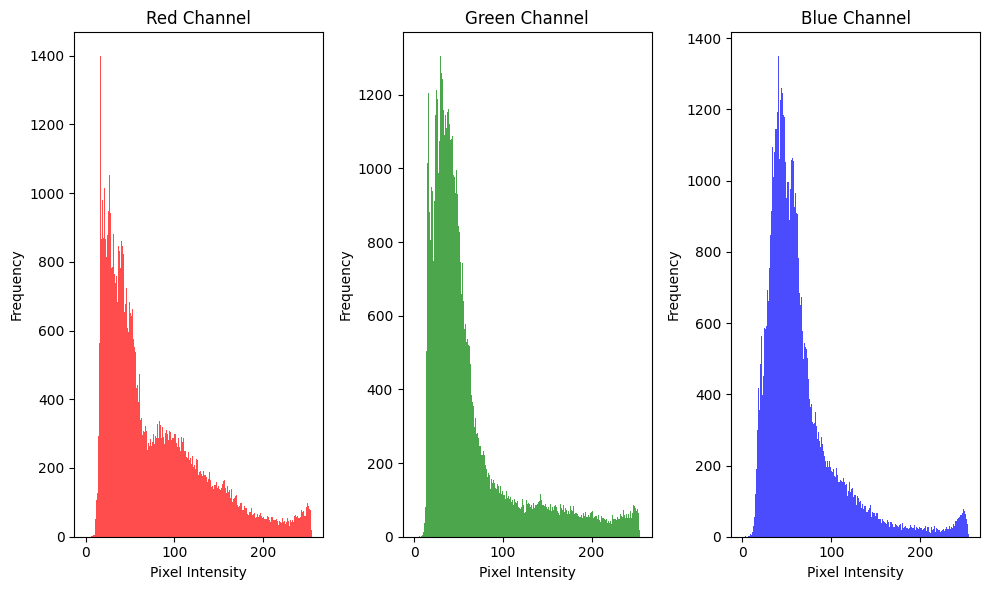

In [102]:
for img, _ in data.take(3):
    for i in range(2):
         plot_rgb_histogram(img[i])
        

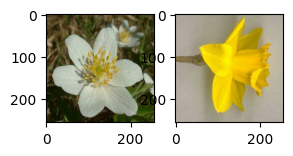

In [108]:
for img, _ in data.take(3):
    for i in range(2):
        plt.subplot(3,4,i+1)
        k=tf.image.random_flip_left_right(img[i])
        plt.imshow(k.numpy().astype('uint8'))

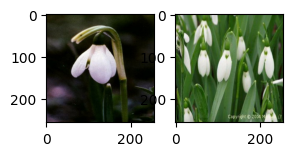

In [109]:
for img, _ in data.take(3):
    for i in range(2):
        plt.subplot(3,4,i+1)
        k=tf.image.random_flip_up_down(img[i])
        plt.imshow(k.numpy().astype('uint8'))